In [1]:
import requests
import pandas as pd
import numpy as np

url = "http://localhost/Chronology/fetch_data.php"
res = requests.get(url)
data = res.json()

df = pd.DataFrame(data)
df.columns = df.columns.str.lower()

df = df.rename(columns={
    "location": "location",
    "locations": "location",
    "count": "crime_count",
    "counts": "crime_count"
})

print(df.head())

    id crime_id        date        day     month  year start_time  end_time  \
0  405     C267  2026-05-05    Tuesday       May  2026   12:39:00  15:39:00   
1  404     C278  2026-05-07   Thursday       May  2026   20:58:00  19:02:00   
2  403     C267  2026-04-29  Wednesday       Apr  2026   12:17:00  14:17:00   
3  402     C256  2026-05-07   Thursday       May  2026   18:01:00  19:06:00   
4  396     C250  2025-11-06   Thursday  November  2025   05:00:00  07:00:00   

   location crime_type crime_count  
0     murud   accident           2  
1     mahad     murder           8  
2     mahad   accident           4  
3    alibag      theft           8  
4  Revdanda    Robbery           3  


In [2]:
df['crime_count'] = pd.to_numeric(df['crime_count'], errors='coerce')
df = df.dropna()
df['crime_count'] = df['crime_count'].astype(float)

In [11]:
from sklearn.preprocessing import StandardScaler

X = df[['crime_count']].values

noise = np.random.normal(0, 20, size=X.shape)
X = X + noise

threshold = df['crime_count'].mean()
y = (df['crime_count'] > threshold).astype(int)

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=4),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC()
}


ALGORITHM: Logistic Regression
Accuracy  : 46.67%
Precision : 54.35%
Recall    : 36.76%
F1 Score  : 43.86%

 CONFUSION MATRIX:
[[31 21]
 [43 25]]

 METRIC BREAKDOWN:
True Negative (TN): 31
False Positive (FP): 21
False Negative (FN): 43
True Positive (TP): 25


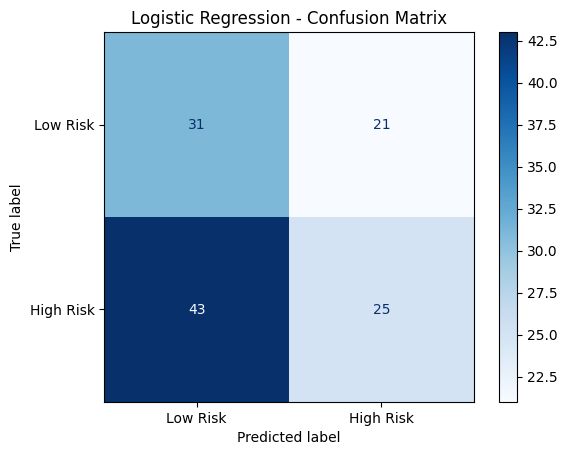


ALGORITHM: Decision Tree
Accuracy  : 48.33%
Precision : 68.75%
Recall    : 16.18%
F1 Score  : 26.19%

 CONFUSION MATRIX:
[[47  5]
 [57 11]]

 METRIC BREAKDOWN:
True Negative (TN): 47
False Positive (FP): 5
False Negative (FN): 57
True Positive (TP): 11


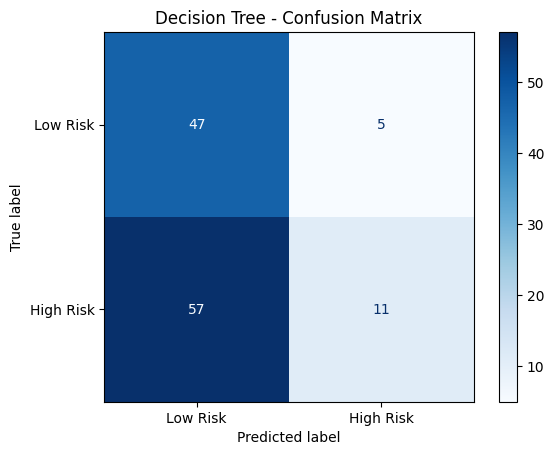


ALGORITHM: Random Forest
Accuracy  : 58.33%
Precision : 65.00%
Recall    : 57.35%
F1 Score  : 60.94%

 CONFUSION MATRIX:
[[31 21]
 [29 39]]

 METRIC BREAKDOWN:
True Negative (TN): 31
False Positive (FP): 21
False Negative (FN): 29
True Positive (TP): 39


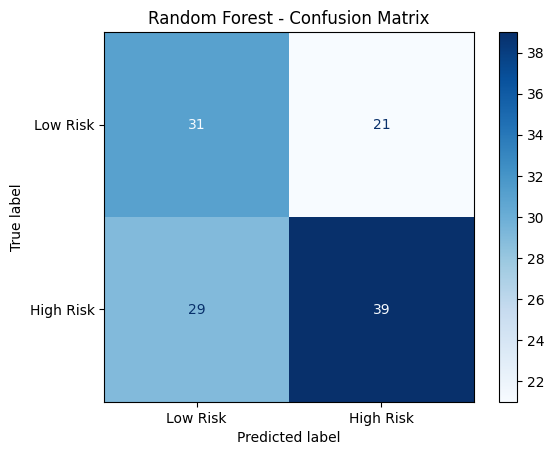


ALGORITHM: KNN
Accuracy  : 58.33%
Precision : 64.06%
Recall    : 60.29%
F1 Score  : 62.12%

 CONFUSION MATRIX:
[[29 23]
 [27 41]]

 METRIC BREAKDOWN:
True Negative (TN): 29
False Positive (FP): 23
False Negative (FN): 27
True Positive (TP): 41


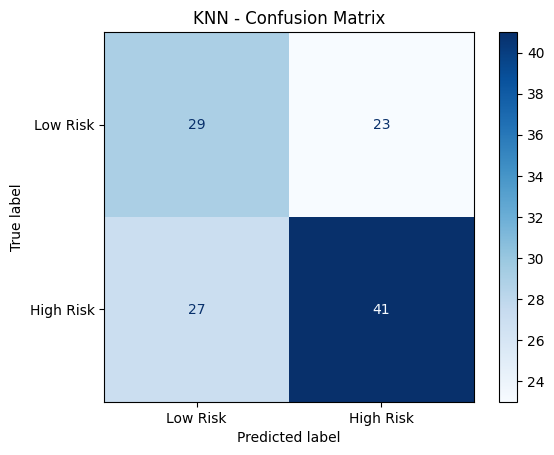


ALGORITHM: SVM
Accuracy  : 50.83%
Precision : 56.92%
Recall    : 54.41%
F1 Score  : 55.64%

 CONFUSION MATRIX:
[[24 28]
 [31 37]]

 METRIC BREAKDOWN:
True Negative (TN): 24
False Positive (FP): 28
False Negative (FN): 31
True Positive (TP): 37


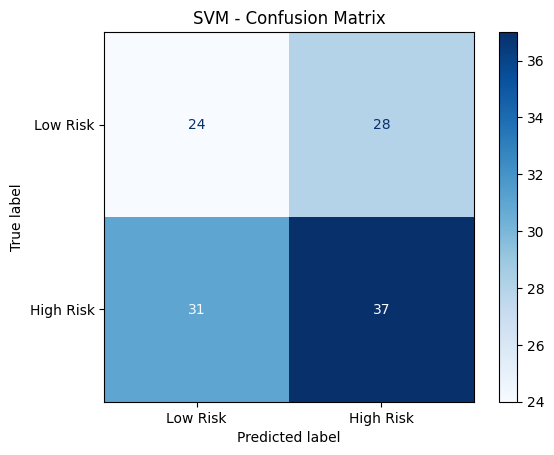

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

for name, model in models.items():

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    acc = accuracy_score(y_test, pred) * 100
    prec = precision_score(y_test, pred, zero_division=0) * 100
    rec = recall_score(y_test, pred, zero_division=0) * 100
    f1 = f1_score(y_test, pred, zero_division=0) * 100

    print("\n==============================")
    print("ALGORITHM:", name)
    print("==============================")

    print(f"Accuracy  : {acc:.2f}%")
    print(f"Precision : {prec:.2f}%")
    print(f"Recall    : {rec:.2f}%")
    print(f"F1 Score  : {f1:.2f}%")

   
    cm = confusion_matrix(y_test, pred)
    tn, fp, fn, tp = cm.ravel()

    print("\n CONFUSION MATRIX:")
    print(cm)

    print("\n METRIC BREAKDOWN:")
    print(f"True Negative (TN): {tn}")
    print(f"False Positive (FP): {fp}")
    print(f"False Negative (FN): {fn}")
    print(f"True Positive (TP): {tp}")


    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Low Risk", "High Risk"]
    )

    disp.plot(cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.show()

    results.append([name, acc, prec, rec, f1])

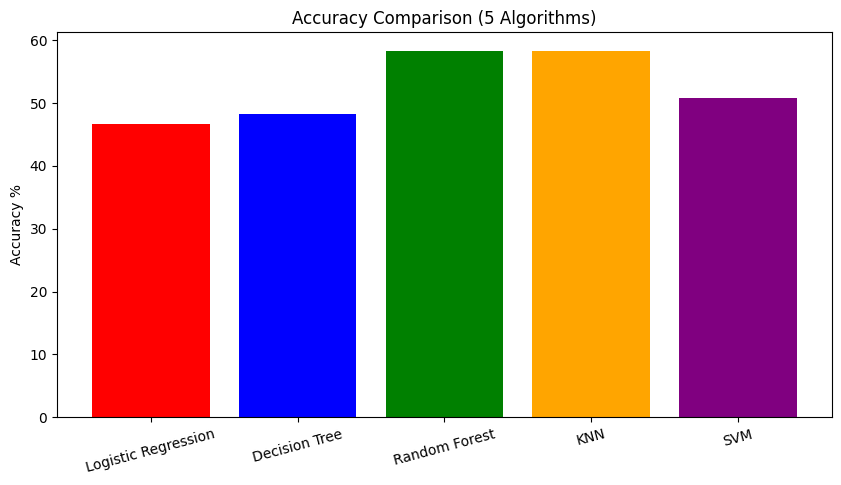

In [7]:
algos = [r[0] for r in results]
acc = [r[1] for r in results]

plt.figure(figsize=(10,5))
plt.bar(algos, acc, color=['red','blue','green','orange','purple'])
plt.title("Accuracy Comparison (5 Algorithms)")
plt.xticks(rotation=15)
plt.ylabel("Accuracy %")
plt.show()

In [8]:
ranking = sorted(results, key=lambda x: x[1], reverse=True)

print("\n===== FINAL RANKING =====\n")

for i, r in enumerate(ranking, 1):
    print(f"{i}. {r[0]} → {r[1]:.2f}%")


===== FINAL RANKING =====

1. Random Forest → 58.33%
2. KNN → 58.33%
3. SVM → 50.83%
4. Decision Tree → 48.33%
5. Logistic Regression → 46.67%
